# **Support Vector Machine (SVM)**

In [ ]:
# pode ser usado pra modelos de classificacao, regressao, mas com foco maior em classificacao.
# O desafio de um SVM e encontrar qual plano faz melhor divisao das nossas classes

Pontos Positivos SVM


In [ ]:
# Funciona muito bem com margem de separacao clara
# E eficaz nos casos em que o numero de dimensoes e maior que o numero de amostras
# ele usa um subconjunto de pontos de treinamento na funcao de decisao (chamados de vetores de suporte), portanto, tambem e eficiente em termos de MEMORIA.

Pontos Negativos SVM

In [ ]:
# Nao tem um bom desempenho quando temos um grande conjunto de dados porque o tempo de treinamento necessario e grande
# Ele tambem nao funciona muito bem quando o conjunto de dados tem mais ruido, ou seja, as classes de destino estao sobrepostas.

In [ ]:
# Implementando UM SVC (Support Vector Classifier) com sklearn
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.pipeline import make_pipeline #pipeline e uma sequencia de comandos que serao executados dentro do modelo

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
# Leitura de dados
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# Separacao de conjuntos
X = df.drop(columns=['Outcome'])
y = df['Outcome']

x_treino, x_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=101)

In [ ]:
# Instanciando a pipeline com modelo SVC
clf = make_pipeline(StandardScaler(), SVC())
# ele define qual a primeira etapa e qual a segunda etapa, aplicando as tais

In [ ]:
# Treinamento do modelo
clf.fit(x_treino, y_treino)

Pipeline(steps=[('standardscaler', StandardScaler()), ('svc', SVC())])

In [ ]:
# Previsoes com modelo
pred = clf.predict(x_teste)

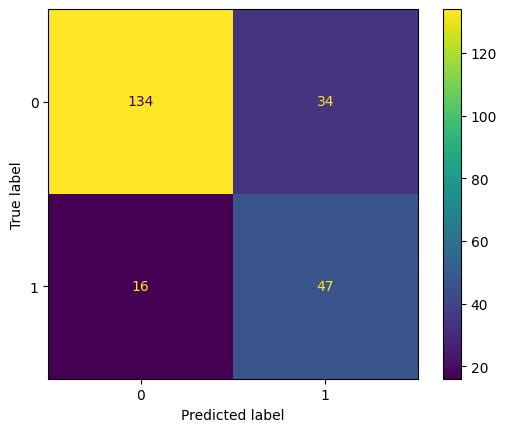

In [ ]:
# Avaliacao de modelo
matriz_confusao = confusion_matrix(pred, y_teste)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao,
                              display_labels=clf.classes_)
disp.plot()

In [ ]:
# Calculando a acuracia
print(accuracy_score(pred, y_teste))
# acuracia inicial de 78% (igual a acuracia do melhor modelo obtido ate agora (KNN))

0.7835497835497836


In [ ]:
# File Tunning (buscando a melhora da performance do modelo
# Modificando Kernel (que pode ser linear, poly, rbf, sigmoid, precomputed)
# default do kernel e o rbf

In [ ]:
def train_test_model(modelo):
  modelo.fit(x_treino, y_treino)
  pred = modelo.predict(x_teste)
  print(accuracy_score(pred, y_teste))

In [ ]:
for kernel in ['linear', 'poly', 'rbf', 'sigmoid']:
  print(kernel)
  clf = make_pipeline(StandardScaler(), SVC(kernel=kernel))
  train_test_model(clf)
  # desempenho de acordo com cada kernel (por enquanto, o melhor resultado obtido e o de rbf, o padrao de kernel)

linear
0.7662337662337663
poly
0.7575757575757576
rbf
0.7835497835497836
sigmoid
0.7142857142857143


In [ ]:
# parametros de regularizacao (define o quao forte vai ser a regularizacao)
# precia ser positivo e usa c
for c in np.arange(0.1, 0.4, 0.05):
  print('Valor do parametro:', c)
  clf = make_pipeline(StandardScaler(), SVC(C=c))
  train_test_model(clf)
  print('='*100)
# 0.3 e o melhor parametro (79%, 0.79)

Valor do parametro: 0.1
0.7489177489177489
Valor do parametro: 0.15000000000000002
0.7965367965367965
Valor do parametro: 0.20000000000000004
0.7878787878787878
Valor do parametro: 0.25000000000000006
0.7835497835497836
Valor do parametro: 0.30000000000000004
0.7965367965367965
Valor do parametro: 0.3500000000000001
0.7922077922077922
Valor do parametro: 0.40000000000000013
0.7792207792207793


In [ ]:
# Os parametros C e kernel sao os principais de ajustes para modelos em SVC

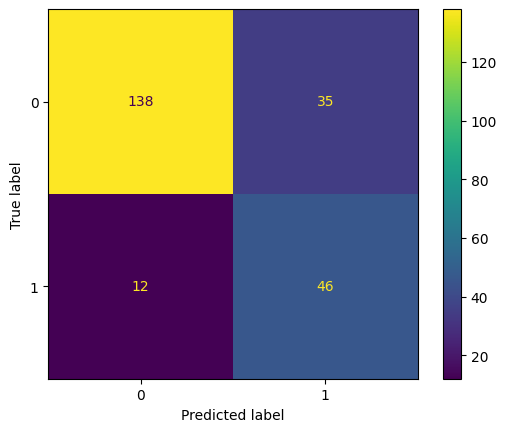

In [ ]:
clf = make_pipeline(StandardScaler(), SVC(C= 0.3, kernel='rbf'))
# Aqui, nao precisa necessariamente indicar que o kernel e rbf, pois sub entende-se que ele e o padrao para svc
clf.fit(x_treino, y_treino)
pred = clf.predict(x_teste)
matriz_confusao = confusion_matrix(pred, y_teste)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao,
                              display_labels=clf.classes_)
disp.plot()

In [ ]:
# calculando acuracia
print(accuracy_score(pred, y_teste))
# acuracia de 0.79*100, ou 79%

0.7965367965367965


In [ ]:
# Conclusoes
# Apesar de ter uma acuracia maior, incrementou os verdadeiros negativos, sacrificando a classificacao correta de casos que eram positivos
# Isso pode ser ruim nesse caso, pois piorou em acertar casos que realmente eram diabetes
# Em razao, disso, deve-se repensar se o modelo de SVM realmente vale a pena por conta disso, apesar de aumentar a acuracia